## Actuall Training

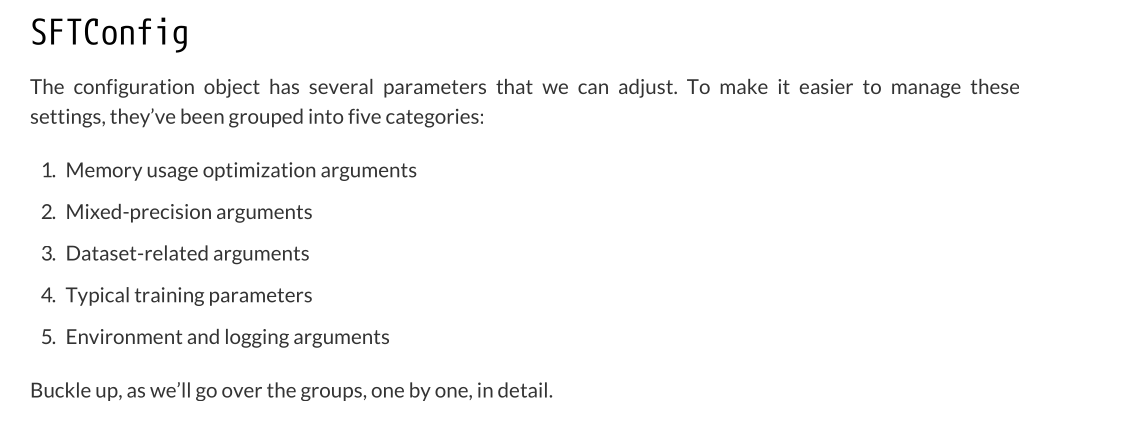

## Gradient Checkpointing

drastically lowers memory requirements by trading compute for memory.

saves memory regardless of which attention implementation you’re using, bringing down peak
memory usage to a similar level across all implementations.

### gradient_checkpointing_kwargs: set it to {'use_reentrant': False} if gradient_checkpointing is
True. 

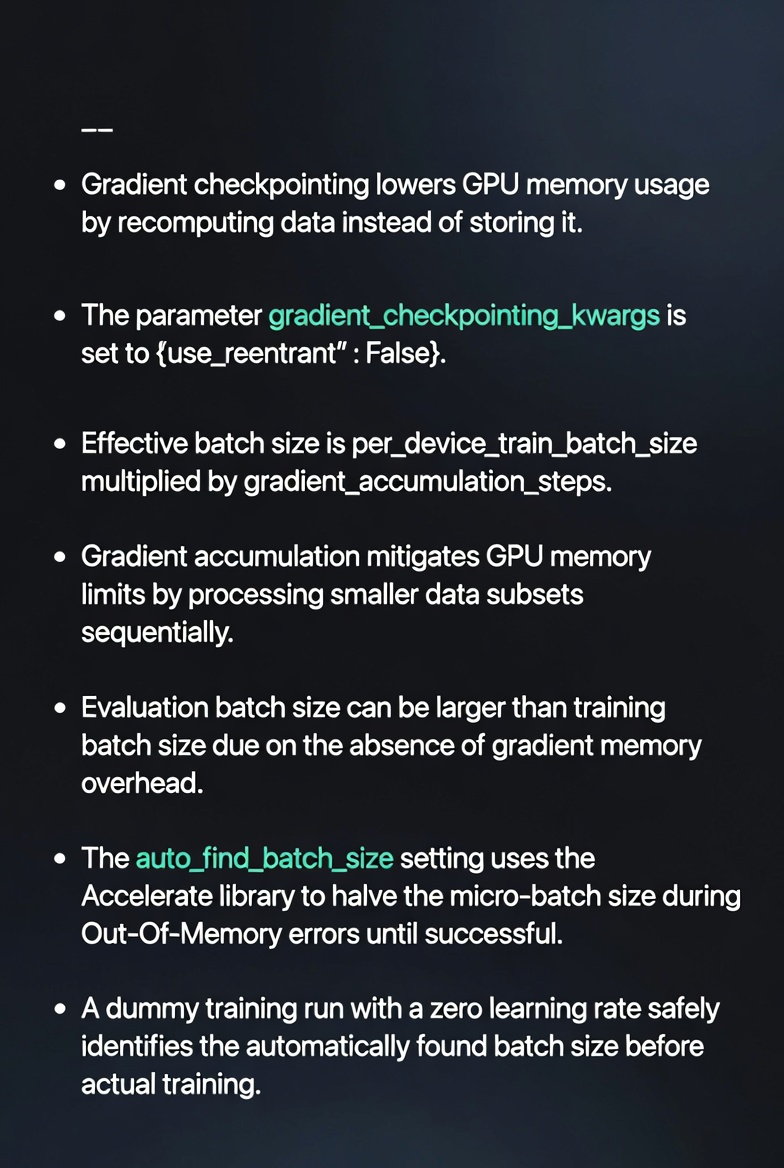

per_device_train_batch_size: this is your micro-batch-size; the default is 8, the number of data
points that will be loaded at once onto the GPU.


he
effective
batch
size
per_device_train_batch_size.
is
given
by
gradient_accumulation_steps
*



If your GPU cannot handle a micro-batch of 8, load as many as you can (4, 2, or 1) and use gradient
accumulation steps to reach an effective batch size of 8.



per_device_eval_batch_size: it also defaults to 8 but you may use a larger size since no gradient
computation occurs during evaluation (giving you some more free memory).





auto_find_batch_size: False by default, it requires the Accelerate library to be installed.

▪ It starts by trying to use the configured per_device_train_batch_size, your micro-batch size.

▪ If it bumps into an OOM error, it halves the micro-batch size and tries again.

▪ It stops trying when it either completes a successful run or, if not even a micro-batch of one fits,
raises an exception.

## Mixed-Precision Arguments

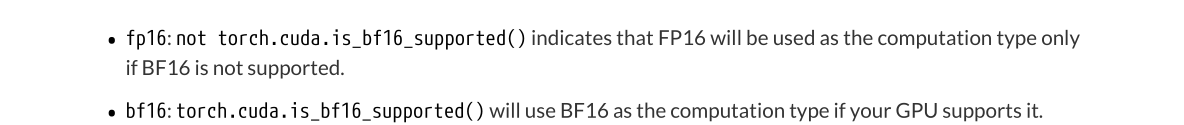

You can also keep both arguments False (their defaults) and your model will remain performing computation in
full precision (FP32).

## BF16 for mixed precision may lead to memory savings

(the notable exception, as always, is the layer norms).

In [ ]:
import torch

def peft_module_casting_to_bf16(model):
    for name, module in model.named_modules():
        # Keep LayerNorm and anything with 'norm' in float32
        if isinstance(module, torch.nn.LayerNorm) or "norm" in name:
            module = module.to(torch.float32)
        
        # Convert specific modules to bfloat16 if weight is float32
        elif any(x in name for x in ["lm_head", "embed_tokens", "wte", "wpe"]):
            if hasattr(module, "weight") and module.weight.dtype == torch.float32:
                module = module.to(torch.bfloat16)

In [6]:
import numpy as np
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, Dataset
from peft import get_peft_model, prepare_model_for_kbit_training, LoraConfig, \
AutoPeftModelForCausalLM
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForCausalLM,\
BitsAndBytesConfig
from trl import SFTTrainer, SFTConfig 

Model  : facebook/opt-350m  (your model, kept as-is)
Dataset: dvgodoy/yoda_sentences

* `formatting_func` — converts `prompt` / `completion` columns to chat format

*  `modules_to_save=["lm_head"]` — required when tokenizer adds new tokens

* `modify_tokenizer()`, `add_template()`, `modify_model()` — custom helper functions unchanged

*  `completion_only_loss`, `packing`, `max_length` 

In [12]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset



# config

In [14]:
BASE        = "facebook/opt-350m"
ADAPTER_DIR = "./lora3"

###   QUANTIZATION

In [16]:


compute_dtype = (
    torch.bfloat16 if torch.cuda.is_bf16_supported(including_emulation=False)
    else torch.float16   # float16 over float32 — OPT-350m trains stably in fp16
)



nf4_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype,
)



#   TOKENIZER

custom helpers are kept exactly as we  had them

If modify_tokenizer / add_template add new tokens

the LoraConfig below includes modules_to_save=["lm_head"]

so the model actually learns to generate those tokens

Without this, new tokens are added but the lm_head that

maps to them stays frozen — silent degraded output

## tokenizer helper function 

In [17]:
# tokenizer: Modify Tokenizer
# ------------------------
def modify_tokenizer(
    tokenizer,
    alternative_bos_token='<|im_start|>',
    alternative_unk_token='<unk>',
    special_tokens=None,
    tokens=None
):
    """
    Modifies a tokenizer by ensuring special tokens are correctly set and optionally adding
    new special tokens or regular tokens.
    """
    eos_token, bos_token = tokenizer.eos_token, tokenizer.bos_token
    pad_token, unk_token = tokenizer.pad_token, tokenizer.unk_token

    # Ensure BOS token is different from EOS
    if bos_token == eos_token:
        bos_token = alternative_bos_token

    # Ensure UNK token is different from EOS
    if unk_token == eos_token:
        unk_token = alternative_unk_token

    # Ensure PAD token is different from EOS (can be same as UNK)
    if pad_token == eos_token:
        pad_token = unk_token

    # Assertions to avoid conflicts
    assert bos_token != eos_token, "Choose a different BOS token."
    assert unk_token != eos_token, "Choose a different UNK token."

    # Create dictionary of tokens to add
    special_tokens_dict = {
        'bos_token': bos_token,
        'pad_token': pad_token,
        'unk_token': unk_token
    }

    # Add additional special tokens if provided
    if special_tokens is not None and isinstance(special_tokens, list):
        special_tokens_dict.update({'additional_special_tokens': special_tokens})

    tokenizer.add_special_tokens(special_tokens_dict)

    # Add regular tokens if provided
    if tokens is not None and isinstance(tokens, list):
        tokenizer.add_tokens(tokens)

    return tokenizer




In [18]:
# tokenizer: Chat Template Helpers
# -----------------------------
def jinja_template(tokenizer):
    """
    Creates a ChatML-compatible Jinja template using BOS/EOS tokens.
    """
    return (
        "{% for message in messages %}"
        f"{{{{'{tokenizer.bos_token}' + message['role'] + '\\n' + message['content'] + '{tokenizer.eos_token}' + '\\n'}}}}"
        "{% endfor %}"
        "{% if add_generation_prompt %}"
        f"{{{{ '{tokenizer.bos_token}assistant\\n' }}}}"
        "{% endif %}"
    )


def add_template(tokenizer, chat_template=None):
    """
    Assigns a chat template to the tokenizer.
    If no template is provided, it creates one using jinja_template.
    """
    if chat_template is None:
        chat_template = jinja_template(tokenizer)
    tokenizer.chat_template = chat_template
    return tokenizer




In [23]:

# tokenizer: Model Helper Functions
# -------------------------------
def get_multiple_of(vocab_size):
    """
    Computes the nearest power-of-two multiple for the vocabulary size.
    Useful for memory alignment when resizing embeddings.
    """
    return 2 ** (bin(vocab_size)[::-1].find('1'))


def modify_model(model, tokenizer):
    """
    Modifies a model to match the tokenizer.
    1. Resizes embeddings if tokenizer length > model vocab size.
       - Ensures embedding size is a multiple of 2**n for memory alignment.
    2. Updates model.config and model.generation_config token IDs (BOS, EOS, PAD)
       - Ensures training and generation work correctly with new tokens.
    """
    # Resize embeddings if needed
    if len(tokenizer) > model.config.vocab_size:
        pad_to_multiple_of = get_multiple_of(model.config.vocab_size)
        model.resize_token_embeddings(len(tokenizer), pad_to_multiple_of=pad_to_multiple_of)

    # Update token IDs in model config
    if getattr(model, "config", None) is not None:
        model.config.pad_token_id = tokenizer.pad_token_id
        model.config.bos_token_id = tokenizer.bos_token_id
        model.config.eos_token_id = tokenizer.eos_token_id

    # Update token IDs in generation config
    if getattr(model, "generation_config", None) is not None:
        model.generation_config.pad_token_id = tokenizer.pad_token_id
        model.generation_config.bos_token_id = tokenizer.bos_token_id
        model.generation_config.eos_token_id = tokenizer.eos_token_id

    return model

In [19]:


tokenizer = AutoTokenizer.from_pretrained(BASE)
tokenizer = modify_tokenizer(tokenizer)   ## pad = unk, never eos ✅


tokenizer = add_template(tokenizer)       # ChatML Jinja template ✅


tokenizer.padding_side = "right"          # ✅ right padding for causal LM



### conform

In [20]:
print(f"eos_token  : {tokenizer.eos_token!r:20}  id={tokenizer.eos_token_id}")
print(f"bos_token  : {tokenizer.bos_token!r:20}  id={tokenizer.bos_token_id}")
print(f"pad_token  : {tokenizer.pad_token!r:20}  id={tokenizer.pad_token_id}")
print(f"unk_token  : {tokenizer.unk_token!r:20}  id={tokenizer.unk_token_id}")
print(f"padding_side: {tokenizer.padding_side}")

eos_token  : '</s>'                id=2
bos_token  : '<|im_start|>'        id=50265
pad_token  : '<pad>'               id=1
unk_token  : '<unk>'               id=3
padding_side: right


# model

##  resize embeddings + sync token IDs ✅

In [24]:
model = AutoModelForCausalLM.from_pretrained(
    BASE,
    device_map="cuda:0",
    quantization_config=nf4_config,
    dtype=compute_dtype,
)
model = modify_model(model, tokenizer)   # resize embeddings + sync token IDs ✅


Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

# LORA CONFIG

### modify_tokenizer() adds new tokens (bos, pad, unk).


###  modify_model() resizes embeddings to accommodate them.


### But the new embedding rows start as random noise —  they only become meaningful if they're allowed to train.


### modules_to_save does exactly that: these layers are unfrozen and trained in full precision alongside LoRA

"lm_head"     — output projection (vocab logits)   - must train so model can generate new tokens


"embed_tokens" — input embeddings (must train so model understands new tokens
))

# Without this, new token embeddings stay random forever.


In [27]:
lora_cfg = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules="all-linear",
    modules_to_save=["lm_head", "embed_tokens"],  # ← needed because we added tokens we need to update your embed tokens , model to save means from lora , these model will also participate on training
)

## DATASET + FORMATTING


dataset has "prompt" (English) and "completion" (Yoda)
#

columns — not the standard "messages" format

formatting_func converts each row into a string that


matches your ChatML template structure

###  completion_only_loss=True then masks everything up to
### and including "### Yoda: " from the loss, so the model
###  only learns to predict the Yoda translation.
 

In [37]:
raw_dataset = (
    load_dataset("dvgodoy/yoda_sentences", split="train")
    .rename_column("sentence", "prompt")
    .rename_column("translation_extra", "completion")
    .remove_columns(["translation"])
)


In [39]:
dataset[0]

{'prompt': 'The birch canoe slid on the smooth planks.',
 'completion': 'On the smooth planks, the birch canoe slid. Yes, hrrrm.'}

In [40]:
def to_messages(example):
    """
    Convert prompt/completion pairs to the standard messages format.
    assistant_only_loss=True will mask the user turn from the loss,
    so the model only learns to predict the Yoda (assistant) response.
    """
    return {
        "messages": [
            {"role": "user",      "content": example["prompt"]},
            {"role": "assistant", "content": example["completion"]},
        ]
    }
 

In [41]:
dataset = raw_dataset.map(to_messages, remove_columns=["prompt", "completion"])


Map:   0%|          | 0/720 [00:00<?, ? examples/s]

In [42]:
print(dataset[0])


{'messages': [{'content': 'The birch canoe slid on the smooth planks.', 'role': 'user'}, {'content': 'On the smooth planks, the birch canoe slid. Yes, hrrrm.', 'role': 'assistant'}]}


## so we just didi it

convert data to : {'messages': [{'role': 'user', 'content': '...'}, {'role': 'assistant', 'content': '...'}]}
 

#  verify chat template renders correctly with generation tags

In [53]:
sample = tokenizer.apply_chat_template(
    dataset[0]["messages"],
    tokenize=False,
    add_generation_prompt=False,
)


## TRAINER

In [75]:
min_effective_batch_size = 8
lr = 3e-4
num_train_epochs = 10
steps = 50

In [76]:
trainer = SFTTrainer(
    model=model,
    peft_config=lora_cfg,            # base model + peft_config → trainer wraps correctly
    processing_class=tokenizer,
    train_dataset=dataset,
    # NO formatting_func — incompatible with assistant_only_loss ✅
    args=SFTConfig(
        output_dir=ADAPTER_DIR,
 
        # Dataset
        packing=True,
        packing_strategy="bfd",
        max_length=64,
        completion_only_loss=True,    # template has {% generation %} tags ✅
 
        # Memory
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        gradient_accumulation_steps=4,
        per_device_train_batch_size= min_effective_batch_size,
        auto_find_batch_size=True,
 
        # Training
        num_train_epochs=num_train_epochs,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        warmup_ratio=0.03,
        max_grad_norm=0.3,
        optim="adamw_torch_fused",
 
        # Mixed precision
        bf16=torch.cuda.is_bf16_supported(including_emulation=False),
        fp16=not torch.cuda.is_bf16_supported(including_emulation=False),
 
        # Logging
        report_to='tensorboard',
        logging_dir='./logs',
        logging_strategy='steps',
        logging_steps=steps,
        save_strategy='steps',
        save_steps=steps
    ),
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/home/ujjwal/projects/.venv/lib/python3.11/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/home/ujjwal/projects/.venv/lib/python3.11/site-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
[RANK 0] Padding-free training is enabled, but the attention implementation is not set to a supported flash attention variant. Padding-free training flattens batches into a single sequence, and only the following implementations are known to reliably support this: flash_atte

In [77]:
trainer.model.print_trainable_parameters()


trainable params: 58,605,568 || all params: 389,801,984 || trainable%: 15.0347


In [78]:
trainer.train()


Step,Training Loss
50,1.534441
100,0.415743


TrainOutput(global_step=110, training_loss=0.9197598045522516, metrics={'train_runtime': 177.2288, 'train_samples_per_second': 18.225, 'train_steps_per_second': 0.621, 'total_flos': 364836940185600.0, 'train_loss': 0.9197598045522516})

In [79]:
ADAPTER_DIR = "./lora3_2"

In [80]:
trainer.save_model(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)  

print(f"Adapter + tokenizer saved to: {ADAPTER_DIR}")



Adapter + tokenizer saved to: ./lora3_2


In [ ]:
print(generate(peft_model, tokenizer, "There is bacon in this sandwich."))

In [62]:
print(f"   pad_token_id={tokenizer.pad_token_id}  eos_token_id={tokenizer.eos_token_id}  (must differ)")


   pad_token_id=1  eos_token_id=2  (must differ)


In [64]:
def generate(model, tokenizer, prompt, max_new_tokens=64, skip_special_tokens=False):
    
    tokenized_input = tokenizer(
        prompt,
        add_special_tokens=False,
        return_tensors="pt"
    ).to(model.device)

    model.eval()

    gen_output = model.generate(
        **tokenized_input,
        eos_token_id=tokenizer.eos_token_id,
        max_new_tokens=max_new_tokens
    )

    output = tokenizer.batch_decode(
        gen_output,
        skip_special_tokens=skip_special_tokens
    )

    return output[0]

In [81]:
print(generate(model, tokenizer, "There is bacon in this sandwich."))

There is bacon in this sandwich.In this sandwich, bacon is.</s>


## save with good name

In [84]:
trainer.save_model('yoda-adapter') 
tokenizer.save_pretrained('yoda-adapter')  

print(f"Adapter + tokenizer saved to: yoda-adapter ")



Adapter + tokenizer saved to: yoda-adapter 


In [86]:
os.listdir('lora3_2')

['tokenizer_config.json',
 'README.md',
 'chat_template.jinja',
 'adapter_model.safetensors',
 'training_args.bin',
 'adapter_config.json',
 'tokenizer.json']

In [85]:
os.listdir('yoda-adapter')

['tokenizer_config.json',
 'README.md',
 'chat_template.jinja',
 'adapter_model.safetensors',
 'training_args.bin',
 'adapter_config.json',
 'tokenizer.json']

# Saving the Full Model

# above we only save adaptor here now we will save 

we CANNOT merge into a quantized (4-bit) model. The math doesn't work — LoRA weights are in BF16/FP16, base weights are in 4-bit NF4. we must reload the base model in full precision first, then merge.



### reload the model

You reload the model because during training you only saved the LoRA adapter, not the full model.

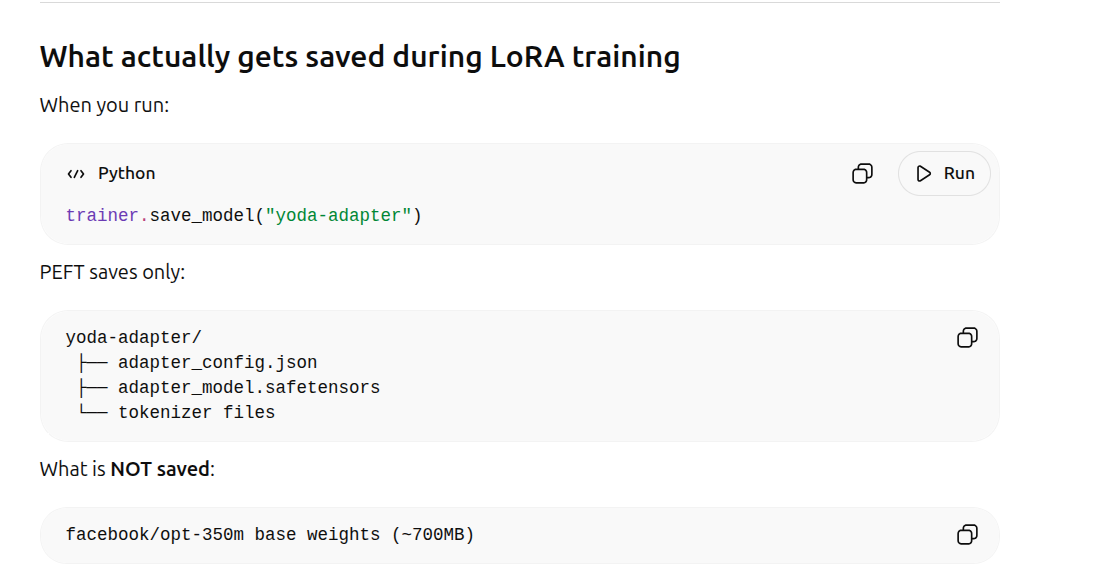

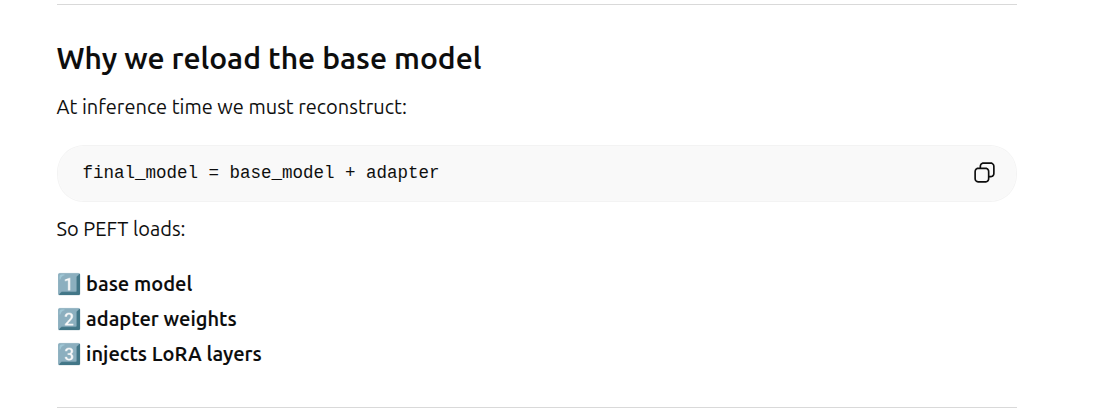

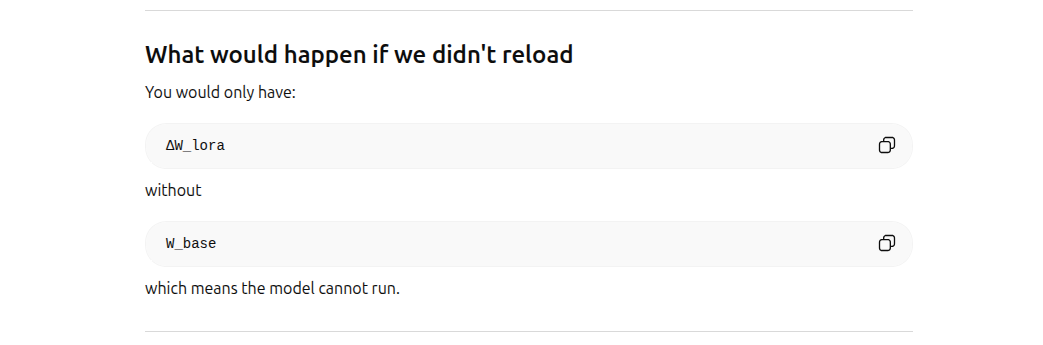

## What AutoPeftModelForCausalLM does

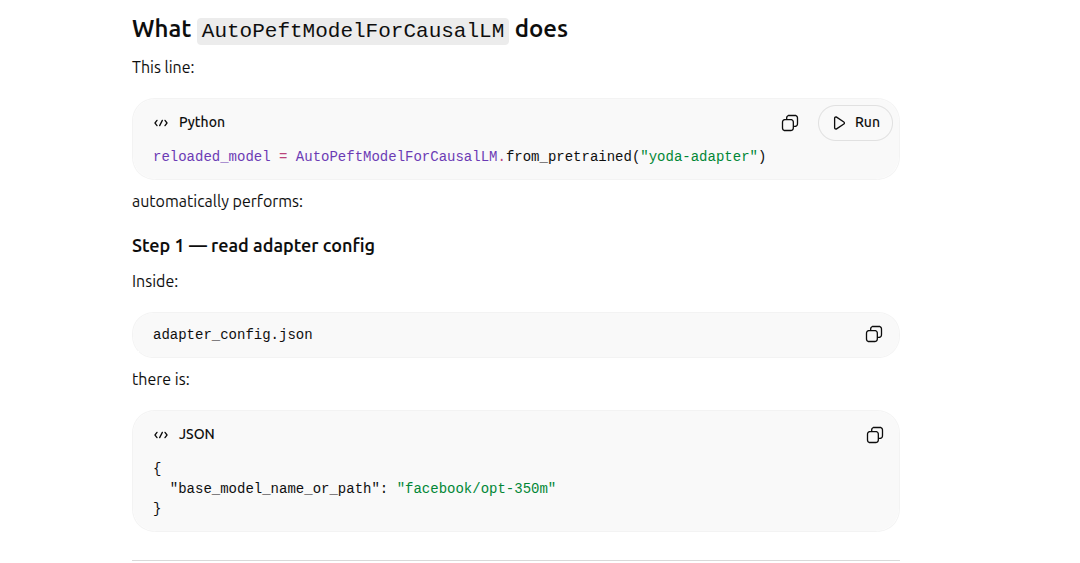

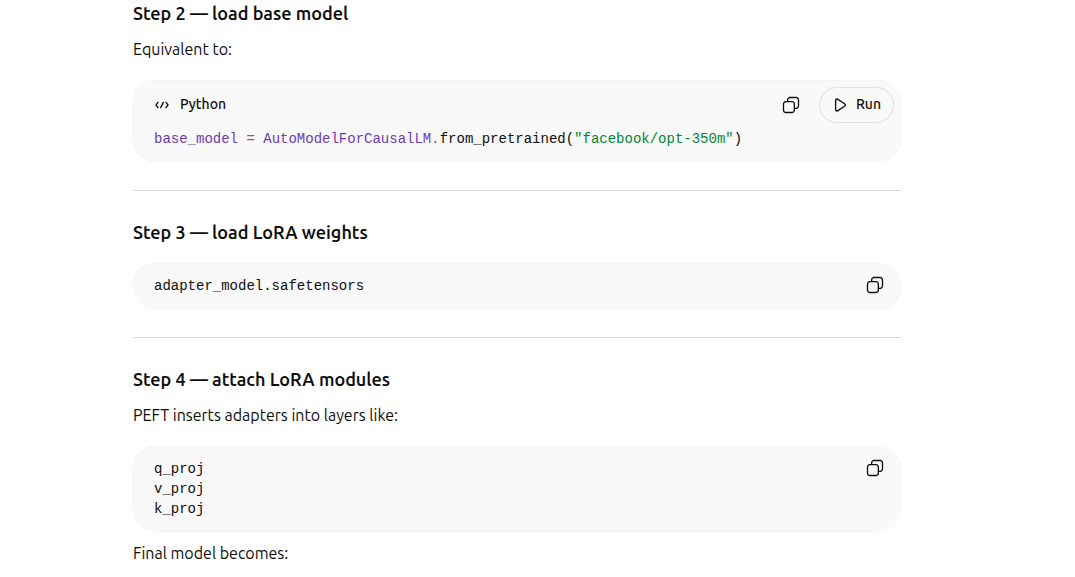

Step 1 — read adapter config

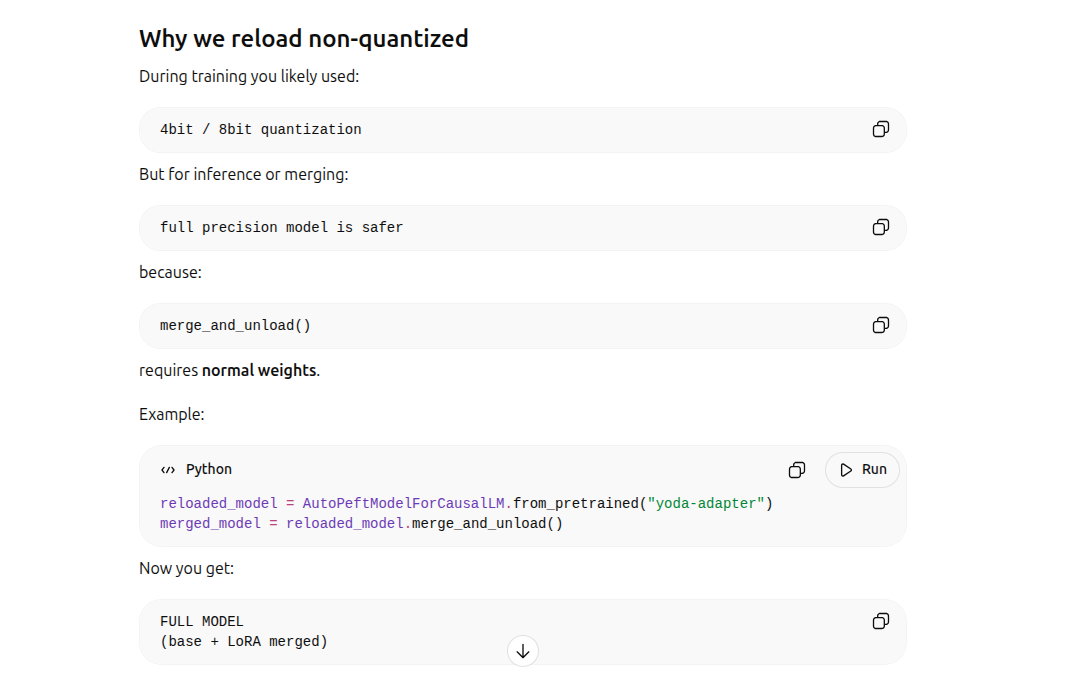

## task

In [91]:
reloaded_model = AutoPeftModelForCausalLM.from_pretrained('yoda-adapter')

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

/home/ujjwal/projects/.venv/lib/python3.11/site-packages/peft/tuners/tuners_utils.py:1225: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


In [92]:
reloaded_model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): OPTForCausalLM(
      (model): OPTModel(
        (decoder): OPTDecoder(
          (embed_tokens): ModulesToSaveWrapper(
            (original_module): Embedding(50272, 512, padding_idx=1)
            (modules_to_save): ModuleDict(
              (default): Embedding(50272, 512, padding_idx=1)
            )
          )
          (embed_positions): OPTLearnedPositionalEmbedding(2050, 1024)
          (project_out): lora.Linear(
            (base_layer): Linear(in_features=1024, out_features=512, bias=False)
            (lora_dropout): ModuleDict(
              (default): Dropout(p=0.05, inplace=False)
            )
            (lora_A): ModuleDict(
              (default): Linear(in_features=1024, out_features=16, bias=False)
            )
            (lora_B): ModuleDict(
              (default): Linear(in_features=16, out_features=512, bias=False)
            )
            (lora_embedding_A): ParameterDict()
            (lora_

We’re finally ready to call the model’s merge_and_unload() method:

In [93]:
merged_model = reloaded_model.merge_and_unload()

In [94]:
merged_model

OPTForCausalLM(
  (model): OPTModel(
    (decoder): OPTDecoder(
      (embed_tokens): Embedding(50272, 512, padding_idx=1)
      (embed_positions): OPTLearnedPositionalEmbedding(2050, 1024)
      (project_out): Linear(in_features=1024, out_features=512, bias=False)
      (project_in): Linear(in_features=512, out_features=1024, bias=False)
      (layers): ModuleList(
        (0-23): 24 x OPTDecoderLayer(
          (self_attn): OPTAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (activation_fn): ReLU()
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=409

## save the full model to disk or push it to the hub

In [95]:
merged_model.save_pretrained('yoda-merged')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [96]:
from huggingface_hub import login
login()

In [97]:
trainer.push_to_hub()

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/ujjwal5454/lora3/commit/950cefd376821de32928b8ae4700c305fcab01d1', commit_message='End of training', commit_description='', oid='950cefd376821de32928b8ae4700c305fcab01d1', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ujjwal5454/lora3', endpoint='https://huggingface.co', repo_type='model', repo_id='ujjwal5454/lora3'), pr_revision=None, pr_num=None)